퍼셉트론은 가중치를 사람이 수동으로 설정해야하지만

신경망은 가중치 매개변수의 적절한 값을 데이터로부터 자동으로 학습하는 능력을 갖추고 있습니다.

#### 퍼셉트론에서 신경망으로

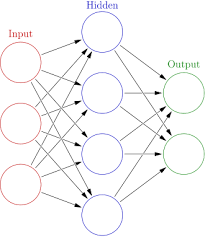

#### 계단함수 구현하기

아래 함수는 인수로 실수(부동소수점)만 받아들입니다. 넘파이 배열을 인수로 넣을 수 없기 때문에 넘파이 배열도 지원하도록 수정해줍시다.

In [ ]:
def step_fuction(x):
  if x>0:
    return 1
  else:
    return 0

In [ ]:
def step_fuction(x):
  y=x>0
  return y.astype(int)

아래 수식의 결과는 bool 배열입니다. 그런데 우리가 원하는 계단 함수는 0이나 1의 'int형'을 출력하는 함수라 배열 y의 원소를 bool에서 int형으로 바꿔줍니다.

In [2]:
import numpy as np
x = np.array([-1.0,1.0,2.0])

y=x>0
print(y)

y = y.astype(int)
print(y)

[False  True  True]
[0 1 1]


계단 함수의 그래프

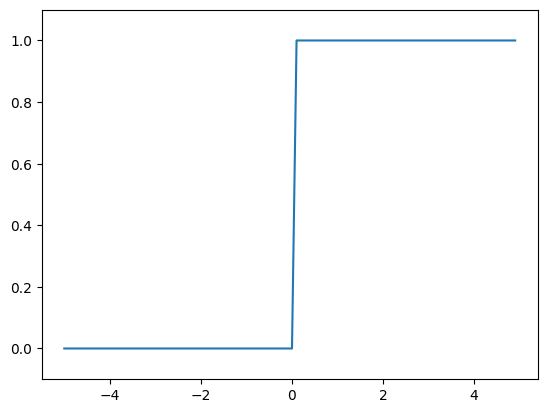

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def step_fuction(x):
  return np.array(x>0, dtype=int)

x = np.arange(-5.0,5.0,0.1)
y=step_fuction(x)
plt.plot(x,y)
plt.ylim(-0.1,1.1)
plt.show()

계단함수는 0을 경계로 출력이 0에서 1(또는 1에서 0)로 바뀝니다.

### 시그모이드 함수 구현하기

In [6]:
def sigmoid(x):
  return 1/(1 + np.exp(-x))

x = np.array([-1.0,1.0,2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

In [5]:
# 브로드캐스트 복습
# 브로드캐스트란 넘파이 배열과 스칼라값의 연산을 넘파이 배열의 원소 각각과 스칼라값의 연산으로 바꿔 수행하는 기능입니다.
t = np.array([1.0,2.0,3.0])
print(1.0 +t)
print(1.0/t)

[2. 3. 4.]
[1.         0.5        0.33333333]


시그모이드 함수 그래프 구현

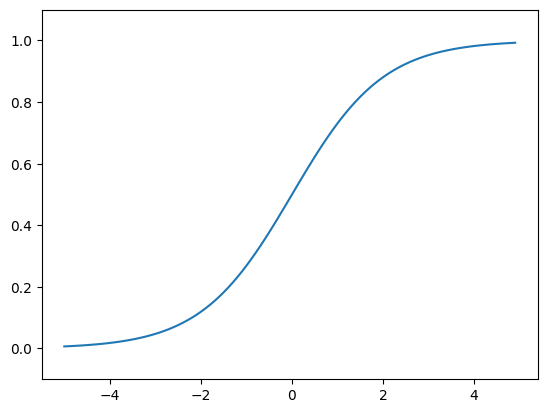

In [8]:
x=np.arange(-5.0,5.0,0.1)
y=sigmoid(x)
plt.plot(x,y)
plt.ylim(-0.1,1.1)
plt.show()

#### 시그모이드 함수와 계단 함수 비교

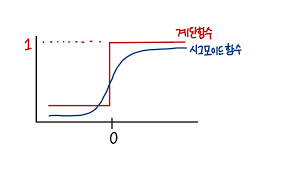

ReLU

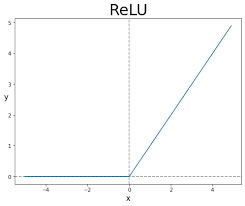

In [ ]:
def relu(x):
  return np.maxinum(0,x)

# maximum은 두 입력 중 큰 값을 선택해 반환하는 함수이다.

In [12]:
import numpy as np
A=np.array([1,2,3,4])
print(A)

print(np.ndim(A))

A.shape

[1 2 3 4]
1


(4,)

In [13]:
B = np.array([[1,2],
              [3,4],
              [5,6]])
print(B)

print(np.ndim(B))
print(B.shape)

[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


신경망에서의 행렬 곱

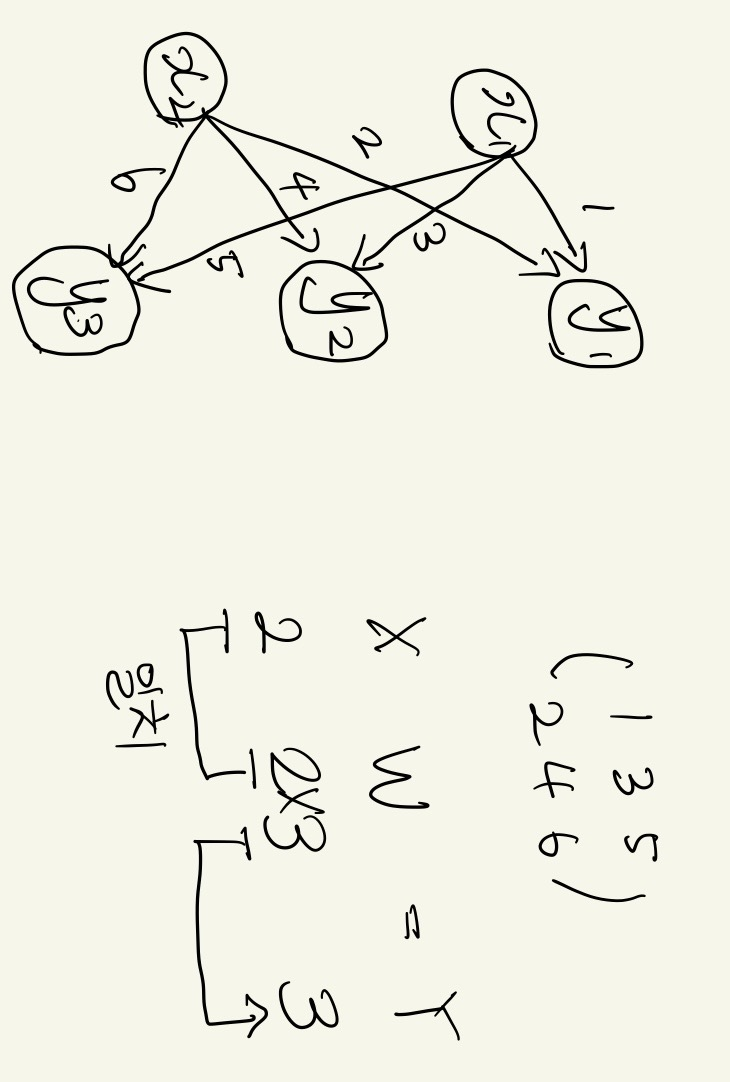

In [15]:
X = np.array([1,2])
W = np.array([[1,3,5],[2,4,6]])
Y = np.dot(X,W)
print(Y)

[ 5 11 17]


3층 신경망 구현하기

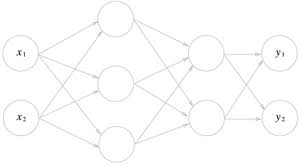

3층 신경망 : 입력층은 2개, 첫 번째 은닉층은 3개, 두 번째 은닉층은 2개, 출력층은 2개의 뉴런으로 구성된다.

넘파이의 다차원 배열을 사용하여 신경망을 구현해보겠습니다. 넘파이 배열을 잘 쓰면 아주 적은 코드만으로 신경망의 순방향 처리를 완성할 수 있습니다.

In [18]:
X = np.array([1.0,0.5])
W1 = np.array([[0.1,0.3,0.5],[0.2,0.4,0.6]])
B1 = np.array([0.1,0.2,0.3])

A1 = np.dot(X,W1)+B1
print(A1)

[0.3 0.7 1.1]


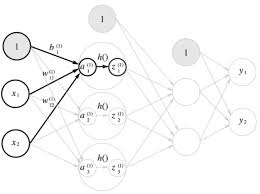

은닉층에서의 가중치 합을 ɑ로 표기하고 활성화 함수 h()로 변환된 신호를 z로 표기합니다.
활성화 함수로 시그모이드 함수를 사용합니다.

In [20]:
z1 = sigmoid(A1)
print(z1)

[0.57444252 0.66818777 0.75026011]


In [22]:
W2 = np.array([[0.1,0.4],[0.2,0.5],[0.3,0.6]])
B2 = np.array([0.1,0.2])

A2 = np.dot(z1,W2)+B2
z2=sigmoid(A2)

In [23]:
def identity_fuction(x):
  return x

W3 = np.array([[0.1,0.3],[0.2,0.4]])
B3 = np.array([0.1,0.2])

A3=np.dot(z2,W3)+B3
Y = identity_fuction(A3)

항등 함수인 identity_fuction()을 정의하고, 이를 출력층의 활성화 함수로 이용했습니다.  항등함수는 입력을 그대로 출력하는 함수입니다.

구현정리

In [24]:
def init_network():
  network={}
  network['W1']=np.array([[0.1,0.3,0.5],[0.2,0.4,0.6]])
  network['B1']=np.array([0.1,0.2,0.3])
  network['W2']=np.array([[0.1,0.4],[0.2,0.5],[0.3,0.6]])
  network['B2']=np.array([0.1,0.2])
  network['W3']=np.array([[0.1,0.3],[0.2,0.4]])
  network['B3']=np.array([0.1,0.2])

  return network

def forward(network,x):
  W1,W2,W3 = network['W1'],network['W2'],network['W3']
  b1,b2,b3 = network['B1'],network['B2'],network['B3']

  a1 = np.dot(x,W1)+b1
  z1=sigmoid(a1)
  a2 = np.dot(z1,W2)+b2
  z2=sigmoid(a2)
  a3=np.dot(z2,W3)+b3
  y=identity_fuction(a3)

  return y

network = init_network()
x =  np.array([1.0,0.5])
y = forward(network,x)
print(y)

[0.31682708 0.69627909]


신경망은 분류와 회귀 모두에 이용할 수 있습니다. 다만 둘 중 어떤 문제냐에 따라 출력층에서 사용하는 활성화 함수가 달라집니다. 일반적으로 회귀에는 항등 함수를, 분류에는 소프트맥스 함수를 사용합니다.